In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## Bayes formula and Markov Processes

In a Markov Process we usually get a sequence of states propagated in time via a certain transition matrix. Each state depends directly on the state before it. 

Due to bayes we can define:
- $p(s_{k-1}, s_{k}) = p(s_{k}|s_{k-1}) \otimes (s_{k-1})$ or the joint for two states wher $\otimes$ means elementwise multiplication.
- $p(s_{k-1}) = \sum_{s_{k}} p(s_{k},s_{k-1})$ 
- $p(s_{k}) = \sum_{s_{k_1}} p(s_{k},s_{k-1}) = p(s_{k}|s_{k-1})p(s_{k-1}) = Ps$ or the marginals
<!-- - $p(s_{k-1}|s_{k}) = \frac{p(s_{k}|s_{k-1})p(s_{k-1})}{p(s_{k})}$ or the posterior of being at a given state at a given time point??? this is not straightforward (https://www.randomservices.org/random/markov/TimeReversal.html) -->


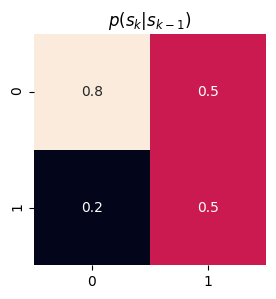

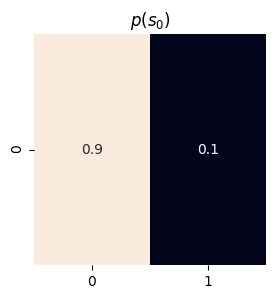

In [4]:
def plot_heatmap(data,ax=None,title='', figsize=(3,3)):
    # function for plotting matrices as heatmaps
    data = data.round(3)
    if ax == None:
        if figsize == None:
            plt.figure()
        else:
            plt.figure(figsize=figsize)
            
        ax = sns.heatmap(data, annot=True, cbar=False,fmt='g')
    else:
        sns.heatmap(data,annot=True, cbar=False,ax=ax,fmt='g')

    ax.set_title(title)
    return ax

trans_matrix = np.array([[0.8,0.5],[0.2, 0.5]])
p_s0 = np.array([0.9,0.1])

ax = plot_heatmap(trans_matrix, title="$p(s_{k}|s_{k-1})$")
ax = plot_heatmap(p_s0.reshape([1,p_s0.size]), title="$p(s_0)$")



In [5]:
'''Simulate Markov Process for K  steps'''

K = 10
pairwise_marginals = np.zeros([2,2,K])                 # p(s_k,s_k-1)
posteriors = np.zeros([2,K+1])                         # p(s_k|s_k-1)
prior, posteriors[:,0] = p_s0, p_s0
for k in range(K):
    pairwise_marginals[:,:,k] = trans_matrix*prior
    # print(pairwise_marginals[:,:,k].sum())
    post = pairwise_marginals[:,:,k].sum(axis=1)
    posteriors[:,k+1] = post 
    
    prior = post


In the figures below we can see the Markov process simulated for K=10 steps and the corresponding marginals and pairwise marginals. 

The marginals over states converge very fast and don't change much after k=4.

We can of course see the same convergence in the pairwise marginals for all the factors in the graph $p(s_{k}, s_{k-1})$.





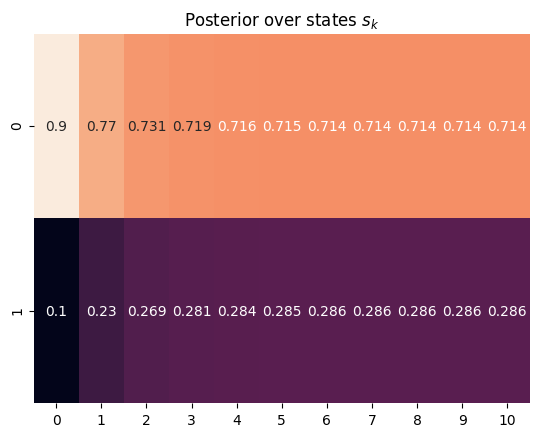

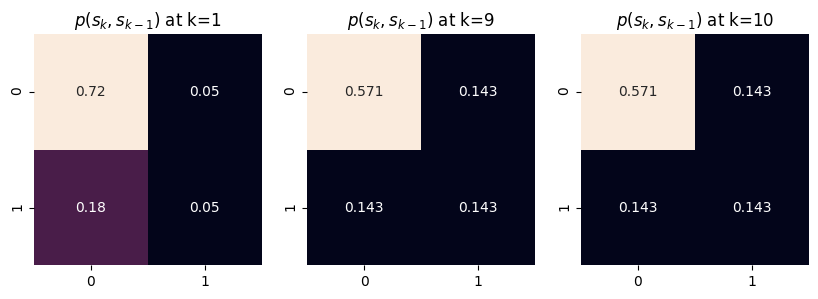

In [6]:

ax = plot_heatmap(posteriors, title = 'Posterior over states $s_k$',figsize=None)

fig, axes = plt.subplots(1,3,figsize=(10,3))
plot_heatmap(pairwise_marginals[...,0], title="$p(s_{k},s_{k-1})$ at " + f"k=1",ax=axes[0])
ai=1
for k in range(K-2, K):
    plot_heatmap(pairwise_marginals[...,k], title="$p(s_{k},s_{k-1})$ at " + f"k={k+1}",ax=axes[ai],figsize=None)
    ai += 1



- Probability of $ p(s_{10}) = \sum_{s_{9}} p(s_{10},s_{9}) = \sum_{s_{10}} p(s_{10},s_{9}) = p(s_{9}) $ 

In [7]:

print('p(s_9) : ',pairwise_marginals[...,K-1].sum(axis=0).round(5))
print('p(s_10): ', pairwise_marginals[...,K-1].sum(axis=1).round(5))



p(s_9) :  [0.71429 0.28571]
p(s_10):  [0.71429 0.28571]


- Probability of $ p(s_{2}) = \sum_{s_{1}} p(s_{2},s_{1}) $
- Probability of $ p(s_{1}) = \sum_{s_{2}} p(s_{2},s_{1}) $ 

In [8]:

print('p(s_1) : ',pairwise_marginals[...,0].sum(axis=0).round(5))
print('p(s_2) : ', pairwise_marginals[...,0].sum(axis=1).round(5))

print("we can see that p(s_1) recovers the prior as it should.")

p(s_1) :  [0.9 0.1]
p(s_2) :  [0.77 0.23]
we can see that p(s_1) recovers the prior as it should.


This is important about the definition of pairwise messages. In BP the pairwise marginal formulas are:

$p(s_{k}, s_{k-1})= p(s_{k}|s_{k-1}) m_{s_{k-2}}(s_{k-1})m_{o_{k-1}}(s_{k-1})m_{o_{k}}(s_{k}) m_{s_{k+1}(s_{k})}$

It is all the messages going into $s_k$ and $s_{k-1}$ <strong>hadamard multiplied</strong> with the transition matrix and this is important since this is how we get a matrix rather than a vector.


Still not clear on the situation with the normalizing constants though. The normalizing constant for the joint should be the sum of the matrix.

Kind of confusing.. Based on sarah's paper however there is a normalizing constant. Her equation looks like this:

$q(s_{k}, s_{k-1}|\pi)= \frac{p(s_{k}|s_{k-1},\pi)}{Z^{\pi}_{k,k-1}} m_{s_{k-2}}(s_{k-1})m_{o_{k-1}}(s_{k-1})m_{o_{k}}(s_{k}) m_{s_{k+1}(s_{k})}$


## Messages of the type $\sum_{s} p(s|r)p(s)$

I find these very confusing but they are actually not. I view these as $\sum_{s} p(r|s)p(s)$ since they differ from $\sum_{s} p(s|r)p(s)$ only up to a <strong>vector</strong> of constants as demonstrated below. How does that vector of constants depend on things? Does it matter?

p(r) =  [0.9 0.1 0. ]


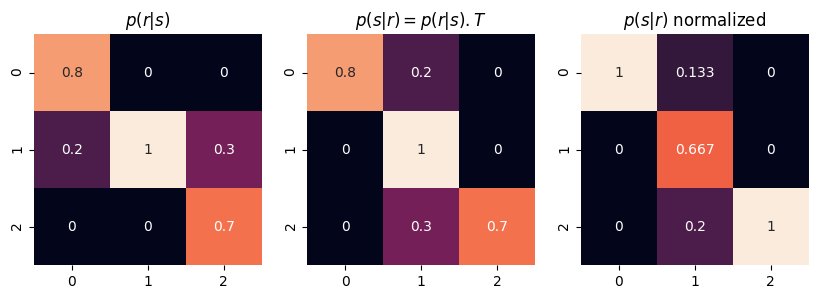

In [9]:
# CORRECT

p_r_given_s = np.array([[0.8, 0, 0],[0.2, 1, 0.3],[0,0,0.7]])
p_s_given_r = p_r_given_s.T
p_s_given_r_norm = p_s_given_r/p_s_given_r.sum(axis=0)

p_r = np.array([0.9,0.1, 0])

print('p(r) = ', p_r)

titles = ["$p(r|s)$", "$p(s|r)= p(r|s).T$", "$p(s|r)$ normalized"]
fig, axes = plt.subplots(1,3, figsize=(10,3))

for ax, data, title in zip(axes, [p_r_given_s, p_s_given_r, p_s_given_r_norm], titles):
    plot_heatmap(data, title=title, ax=ax)


In [10]:
unnorm = p_s_given_r.dot(p_r)
norm = p_s_given_r_norm.dot(p_r)

print("p(r) when using unnormalized p(r|s): ", unnorm)
print("p(r) when using   normalized p(r|s): ", norm)
print("\nratio between the normalized and unnormalized p(r): ", unnorm/norm)

unnorm/norm
norm/unnorm

print("\nnormalizing contants for getting p(s|r): ", p_r_given_s.sum(axis=1))

p(r) when using unnormalized p(r|s):  [0.74 0.1  0.03]
p(r) when using   normalized p(r|s):  [0.91333333 0.06666667 0.02      ]

ratio between the normalized and unnormalized p(r):  [0.81021898 1.5        1.5       ]

normalizing contants for getting p(s|r):  [0.8 1.5 0.7]


## How to build the joint probability $p(s_{1:T})$

The joint of $p(s_1,s_2)$ is constructed as follows by calculating $p(s_k|s_{k-1})\otimes p(s_k)$. This is what we end up with:
$$
\begin{bmatrix}
p(s_2=0|s_1=0)p(s_1=0) & p(s_2=0|s_1=1)p(s_1=1) \\

p(s_2=1|s_1=0)p(s_1=0) & p(s_2=1|s_1=1)p(s_1=1) 
\end{bmatrix} 
$$


To calculate $p(s_1, s_2, s_3)$ we need the following $p(s_k|s_{k-1})\otimes p(s_{k-1}) \otimes p(s_{k+1}|s_{k})$

$$
p(s_1,s_2,s_3=0) = 
\begin{bmatrix}
p(s_2=0|s_1=0)p(s_1=0)p(s_3=0|s_2=0) & p(s_2=0|s_1=1)p(s_1=1)p(s_3=0|s_2=0)\\

p(s_2=1|s_1=0)p(s_1=0)p(s_3=0|s_2=1) & p(s_2=1|s_1=1)p(s_1=1)p(s_3=0|s_2=1) 
\end{bmatrix} 
$$

$$
p(s_1,s_2,s_3=1) = 
\begin{bmatrix}
p(s_2=0|s_1=0)p(s_1=0)p(s_3=1|s_2=0) & p(s_2=0|s_1=1)p(s_1=1)p(s_3=1|s_2=0)\\

p(s_2=1|s_1=0)p(s_1=0)p(s_3=1|s_2=1) & p(s_2=1|s_1=1)p(s_1=1)p(s_3=1|s_2=1) 
\end{bmatrix} 
$$

The point here is that by taking matrix vector products but instead hadamard products we do not do the marginalization.

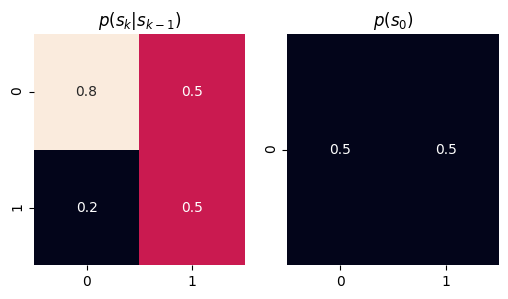

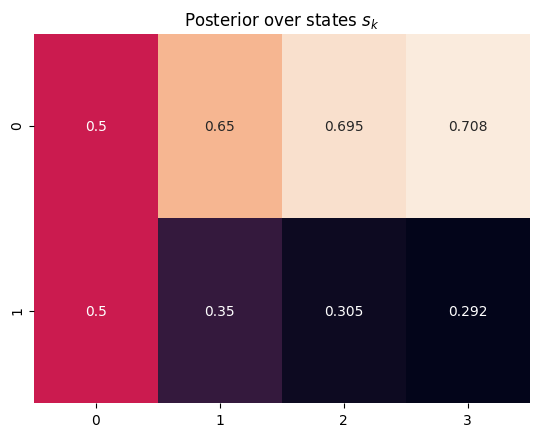

In [11]:
"Take Markov Process from chain above and simulate for 3 steps"

trans_matrix = np.array([[0.8,0.5],[0.2, 0.5]])
p_s0 = np.array([0.5,0.5])

fig, ax = plt.subplots(1,2, figsize=(6,3))
plot_heatmap(trans_matrix, title="$p(s_{k}|s_{k-1})$",ax=ax[0])
plot_heatmap(p_s0.reshape([1,p_s0.size]), title="$p(s_0)$",ax=ax[1])

'''Simulate Markov Process for 3  steps'''

K = 3
pairwise_marginals = np.zeros([2,2,K])                 # p(s_k,s_k-1)
posteriors = np.zeros([2,K+1])                         # p(s_k|s_k-1)
prior, posteriors[:,0] = p_s0, p_s0
for k in range(K):
    pairwise_marginals[:,:,k] = trans_matrix*prior
    # print(pairwise_marginals[:,:,k].sum())
    post = pairwise_marginals[:,:,k].sum(axis=1)
    posteriors[:,k+1] = post 
    
    prior = post

ax = plot_heatmap(posteriors, title = 'Posterior over states $s_k$',figsize=None)


In [12]:
A = pairwise_marginals[...,0]
B = np.zeros([2,2,2])

# construct joint distribution for p(s_1, s_2, s_3) by taking the pairwise marginals and adding one more transition step as shown above
for i in range(2):
    B[:,:,i] = (A.T*trans_matrix[i,:]).T


print("p(s_1): ", B.sum(axis=(0,2)))   # p(s_1)
print("p(s_2): ", B.sum(axis=(2,1)))   # p(s_2)
print("p(s_3): ", B.sum(axis=(0,1)))   # p(s_3)
print("\np(s1,s2) = \sum_s_3 p(s_1,s_2,s_3)")
print(B.sum(axis=2))
print('which is the same results as what we had before')
print(A)

p(s_1):  [0.5 0.5]
p(s_2):  [0.65 0.35]
p(s_3):  [0.695 0.305]

p(s1,s2) = \sum_s_3 p(s_1,s_2,s_3)
[[0.4  0.25]
 [0.1  0.25]]
which is the same results as what we had before
[[0.4  0.25]
 [0.1  0.25]]


## Try and build BP for this markov chain and see what happens

First we have no observation uncertainty

In [13]:
"""Initialize process"""

T=3
trans_matrix = np.array([[0.8,0.5],[0.2, 0.5]])
p_s0 = np.array([0.5,0.5])
ns = trans_matrix.shape[0]


"""Calculate messages"""
fwd_messages = np.zeros([ns,T])
fwd_messages[:,0] = p_s0
bwd_messages = np.zeros([ns,T]) + 1/ns

for t in np.flip([np.arange(T-1)]):
    bwd_messages[:,t] = bwd_messages[:,t+1].dot(trans_matrix)


for t in range(T-1):
    fwd_messages[:,t+1] = trans_matrix.dot(fwd_messages[:,t])

post = fwd_messages*bwd_messages
post = post/post.sum(axis=0)


"""Print results"""
print('FWD')
display(pd.DataFrame(fwd_messages))
print('BWD')
display(pd.DataFrame(bwd_messages))
print('Posterior')
display(pd.DataFrame(post))

print("We can see that in this case it the backward messages are uninformative, since they do not convey anything because of the their uniformness.")

FWD


,0,1,2
0,0.5,0.65,0.695
1,0.5,0.35,0.305


BWD


,0,1,2
0,0.5,0.5,0.5
1,0.5,0.5,0.5


Posterior


,0,1,2
0,0.5,0.65,0.695
1,0.5,0.35,0.305


We can see that in this case it the backward messages are uninformative, since they do not convey anything because of the their uniformness.


Now we can add observation uncertainty.

,0,1,2
0,0.692308,0.707692,0.712308
1,0.307692,0.292308,0.287692


,0,1,2
0,0.707495,0.756856,0.337477
1,0.292505,0.243144,0.662523


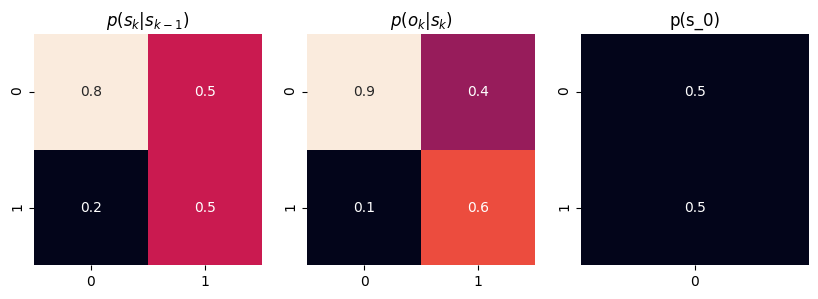

In [45]:
B = np.array([[0.8,0.5],[0.2, 0.5]])
A = np.array([[0.9, 0.4], [0.1, 0.6]])
# A = np.array([[0.5, 0.5], [0.5, 0.5]])
utility = np.array([0.9,0.1])
p_s0 = np.array([0.5,0.5])
ns = A.shape[0]

np.random.seed(2132112)

fig, ax = plt.subplots(1,3, figsize=(10,3))
for ax, data, title in zip(ax, [B,A,p_s0[...,None]], ['$p(s_{k}|s_{k-1})$', '$p(o_k|s_k)$','p(s_0)']):
    plot_heatmap(data, ax=ax,title=title)

"""Calculate message passing and analytic posterior"""

states = np.zeros(T,dtype=int)
observations = np.zeros(T, dtype=int)
analytic_posterior = np.zeros([ns,T,T])

bwd_messages = np.zeros([ns,T,T]) + 1/ns
fwd_messages = np.zeros([ns,T,T])
fwd_messages[:,0,:] = p_s0[...,None]
obs_messages = np.zeros([ns,T,T]) + A.T.dot(p_s0)[...,None,None]  # also initializes to uniform? bit strange

post = np.zeros([ns,T,T])
analytic_post = np.zeros([ns,T,T])


for t in range(T):
    
    states[t] = np.random.choice(np.arange(ns), p=p_s0)
    observations[t] = np.random.choice(np.arange(ns),p=A[:,states[t]])

    if t==0:
        # initialize messages
        for k in np.flip(np.arange(T-1)):
            bwd_messages[:,k,t] = (bwd_messages[:,k+1,t]*obs_messages[:,k+1,t]).dot(B)
            bwd_messages[:,k,t] /= bwd_messages[:,k,t].sum()
    
    # calculate forward messages and perform necessary bwd message updates?
    
    obs_messages[:,t,:] = A[observations[t],:][...,None]

    if t>0:
        for k in np.flip(np.arange(t)):
            bwd_messages[:,k,t] = (bwd_messages[:,k+1,t]*obs_messages[:,k+1,t]).dot(B)
            bwd_messages[:,k,t] /= bwd_messages[:,k,t].sum()
    if t<=T-1:
        for k in range(1,T):
            # print(t)
            fwd_messages[:,k,t] = B.dot(fwd_messages[:,k-1,t]*obs_messages[:,k-1,t]) 
            fwd_messages[:,k,t] /= fwd_messages[:,k,t].sum()

    post[:,:,t] = fwd_messages[:,:,t]*obs_messages[:,:,t]*bwd_messages[:,:,t]
    post[:,:,t] /= post[:,:,t].sum(axis=0)


display(pd.DataFrame(post[:,:,0]))
display(pd.DataFrame(post[:,:,T-1]))

In [46]:
for t in range(T):
    print(observations[t])
    print(bwd_messages[:,:,t])

0
[[0.5 0.5 0.5]
 [0.5 0.5 0.5]]
0
[[0.55172414 0.5        0.5       ]
 [0.44827586 0.5        0.5       ]]
1
[[0.51807229 0.36363636 0.5       ]
 [0.48192771 0.63636364 0.5       ]]


In [34]:
import numpy as np 

a = np.array([0.1, 0.9])
b = np.array([0.4,0.6])

p_a_b = a[:,None]*b

p_a_b.sum(axis=1)

p_a_b /  p_a_b.sum(axis=0)[None,:]
p_a_b

array([[0.04, 0.06],
       [0.36, 0.54]])